# Задача 5. PageRank
## Трубачеев Борис Андреевич, группа S4101
#### Выполнены все подпункты задания.

### 1. Масштабирование на большой граф (5 баллов)

Установка networkx только для скачивания графа

In [1]:
pip install networkx

Note: you may need to restart the kernel to use updated packages.


Функция загрузки графа стенфорда, как на паре

In [2]:
from pathlib import Path
import urllib.request
import gzip
import networkx as nx
import graphblas as gb
from graphblas import dtypes


def load_web_stanford(cache_dir='./snap_datasets'):
    """
    Загружает граф web-Stanford из коллекции SNAP
    и преобразует его в формат GraphBLAS.

    Returns:
    --------
    A : gb.Matrix
        Матрица смежности GraphBLAS

    meta : dict Метаданные графа
    """

    cache_path = Path(cache_dir)
    cache_path.mkdir(exist_ok=True)

    url = 'https://snap.stanford.edu/data/web-Stanford.txt.gz'

    filename = url.split('/')[-1]

    filepath = cache_path / filename
    txt_path = cache_path / filename.replace('.gz', '')

    if not txt_path.exists():

        print("Загрузка web-Stanford...")

        if not filepath.exists():
            urllib.request.urlretrieve(url, filepath)

        with gzip.open(filepath, 'rt') as f_in:
            with open(txt_path, 'w') as f_out:
                for line in f_in:
                    if not line.startswith('#') and line.strip():
                        f_out.write(line)

    print(f"Чтение графа из {txt_path.name}...")

    G = nx.read_edgelist(
        txt_path,
        create_using=nx.DiGraph()
    )

    print("Конвертация в формат GraphBLAS...")

    A = gb.io.from_networkx(
        G,
        dtype=dtypes.UINT8
    )

    meta = {
        'name': 'web-Stanford',
        'n_nodes': A.nrows,
        'n_edges': A.nvals,
        'density': A.nvals / (A.nrows * A.ncols) if A.nrows > 0 else 0,
        'source': 'SNAP'
    }

    print(f"Загружено: {meta['n_nodes']:,} узлов")
    print(f"Загружено: {meta['n_edges']:,} рёбер")
    print(f"Плотность графа: {meta['density']:.2e}")

    return A, meta


A, meta = load_web_stanford()

Чтение графа из web-Stanford.txt...
Конвертация в формат GraphBLAS...
Загружено: 281,903 узлов
Загружено: 2,312,497 рёбер
Плотность графа: 2.91e-05


Реализация базового pagerank с корректной обработкой висячих вершин, как на паре 

In [3]:
import time
import tracemalloc

import graphblas as gb
from graphblas import Vector, dtypes
from graphblas import binary, unary, monoid, semiring


def pagerank_baseline(
    A,
    initial_r=None,
    damping=0.85,
    max_iter=100,
    tol=1e-6,
    verbose=False
):
    n = A.nrows

    A_bin = (
        A.apply(unary.one).new()
        if A.dtype != dtypes.UINT8
        else A
    )

    d_out = A_bin.reduce_rowwise(monoid.plus).new()

    inv_d = Vector(dtypes.FP64, n)

    mask_non_dang = (d_out > 0).new()

    inv_d(mask=mask_non_dang.S) << binary.truediv(
        1.0,
        d_out
    )

    dangling_mask = (d_out == 0).new()

    dangling_float = dangling_mask.dup(dtype=dtypes.FP64)

    r = Vector(dtypes.FP64, n)

    if initial_r is None:
        r[:] << 1.0 / n

    else:
        r << initial_r

    t = Vector(dtypes.FP64, n)

    w = Vector(dtypes.FP64, n)

    diff = Vector(dtypes.FP64, n)

    history = {
        'rdiff': [],
        'dangling_mass': [],
        'iters': 0
    }

    for iteration in range(max_iter):

        t << r

        w << A_bin.T.mxv(
            t.ewise_mult(inv_d, binary.times),
            semiring.plus_times
        )

        if dangling_mask.nvals > 0:

            dangling_mass = (
                t.ewise_mult(
                    dangling_float,
                    binary.times
                )
                .reduce(monoid.plus)
                .value
            )

        else:

            dangling_mass = 0.0

        teleport = (
            (1.0 - damping) +
            damping * dangling_mass
        ) / n

        r << binary.times(
            damping,
            w
        )

        r(binary.plus)[:] << teleport

        diff << (
            t.ewise_add(r, binary.minus)
             .apply(unary.abs)
        )

        rdiff = diff.reduce(monoid.plus).value

        history['rdiff'].append(rdiff)

        history['dangling_mass'].append(dangling_mass)

        history['iters'] = iteration + 1

        if verbose and iteration % 10 == 0:

            current_sum = r.reduce(monoid.plus).value

            print(
                f"Iter {iteration:3d}: "
                f"rdiff={rdiff:.2e}, "
                f"dangling_mass={dangling_mass:.4f}, "
                f"sum_r={current_sum:.6f}"
            )

        if rdiff < tol:

            if verbose:

                print(
                    f"✓ Converged at iteration "
                    f"{iteration + 1}"
                )

            break

    return r, history

Запуск базовой версии pagerank, построение графиков сходимости

🚀 Запуск baseline PageRank...
Iter   0: rdiff=9.58e-01, dangling_mass=0.0000, sum_r=0.999481
Iter  10: rdiff=1.06e-02, dangling_mass=0.0000, sum_r=0.997928
Iter  20: rdiff=1.37e-03, dangling_mass=0.0000, sum_r=0.997666
Iter  30: rdiff=2.22e-04, dangling_mass=0.0000, sum_r=0.997625
Iter  40: rdiff=3.87e-05, dangling_mass=0.0000, sum_r=0.997619
Iter  50: rdiff=6.98e-06, dangling_mass=0.0000, sum_r=0.997618
Iter  60: rdiff=1.29e-06, dangling_mass=0.0000, sum_r=0.997618
✓ Converged at iteration 63

Baseline PageRank завершён за 0.87 сек
Итераций до сходимости: 63
Пиковое потребление памяти: 304.34 MB

Статистика rank vector:
Максимальный rank: 1.127594e-02
Минимальный rank: 5.320979e-07
Сумма рангов: 0.997618

Топ-10 узлов по значению PageRank:
 1. Node    281: 1.127594e-02
 2. Node     67: 9.245758e-03
 3. Node   1352: 8.277510e-03
 4. Node   4898: 3.015921e-03
 5. Node   3367: 2.994130e-03
 6. Node    341: 2.565606e-03
 7. Node    445: 2.447868e-03
 8. Node    443: 2.425000e-03
 9. Node 

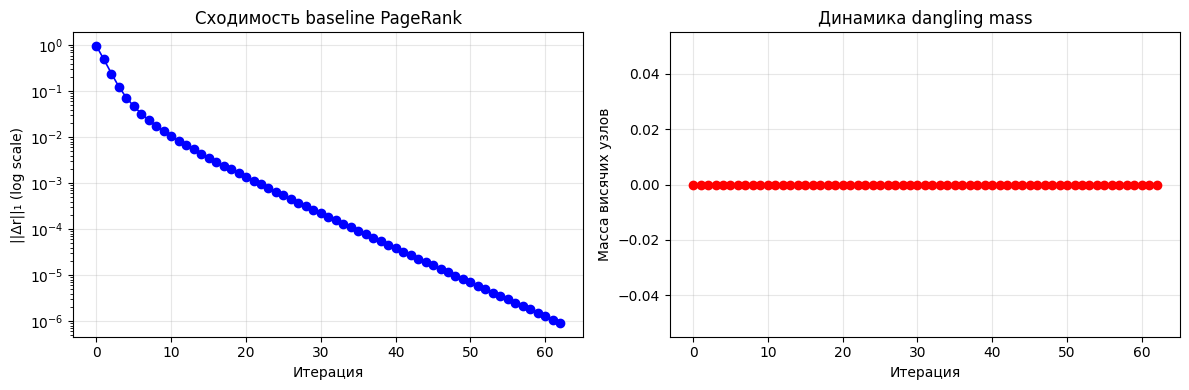

In [4]:
import time
import tracemalloc
import numpy as np
import matplotlib.pyplot as plt


if A is not None:

    print("Запуск baseline PageRank...")

    tracemalloc.start()

    start = time.time()

    r_base, hist_base = pagerank_baseline(
        A,
        damping=0.85,
        max_iter=100,
        tol=1e-6,
        verbose=True
    )

    elapsed = time.time() - start

    current_mem, peak_mem = tracemalloc.get_traced_memory()

    tracemalloc.stop()

    print(f"\n{'='*60}")
    print(f"Baseline PageRank завершён за {elapsed:.2f} сек")
    print(f"Итераций до сходимости: {hist_base['iters']}")
    print(f"Пиковое потребление памяти: "
          f"{peak_mem / (1024**2):.2f} MB")
    print(f"{'='*60}")

    indices = np.array([i for i in range(r_base.size)])

    values = np.array([
        r_base[i].new().value
        if r_base[i].new().value is not None else 0.0
        for i in indices
    ])

    print("\nСтатистика rank vector:")

    print(f"Максимальный rank: {values.max():.6e}")

    print(f"Минимальный rank: {values.min():.6e}")

    print(f"Сумма рангов: {values.sum():.6f}")

    print("\nТоп-10 узлов по значению PageRank:")

    top_k = np.argsort(values)[-10:][::-1]

    for rank, idx in enumerate(top_k, 1):

        print(
            f"{rank:2d}. "
            f"Node {idx:6d}: "
            f"{values[idx]:.6e}"
        )

    max_rank_diff = max(hist_base['rdiff'])

    print(f"\nМаксимальная разница рангов между итерациями: "
          f"{max_rank_diff:.6e}")

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)

    plt.semilogy(
        hist_base['rdiff'],
        'b-o',
        linewidth=1.2
    )

    plt.xlabel('Итерация')

    plt.ylabel('||Δr||₁ (log scale)')

    plt.title('Сходимость baseline PageRank')

    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)

    plt.plot(
        hist_base['dangling_mass'],
        'r-o',
        linewidth=1.2
    )

    plt.xlabel('Итерация')

    plt.ylabel('Масса висячих узлов')

    plt.title('Динамика dangling mass')

    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    plt.show()

    baseline_metrics = {
        'runtime_sec': elapsed,
        'peak_memory_mb': peak_mem / (1024**2),
        'iterations': hist_base['iters'],
        'max_rank_diff': max_rank_diff,
        'max_rank': values.max(),
        'min_rank': values.min(),
        'rank_sum': values.sum()
    }

Оптимизированная версия pagerank с оптимизациями, которые рассматривались на паре:

* Использование FP32 вместо FP64 для сокращения потребления памяти
*  Reuse temporary vectors для переиспользования памяти и сокращения ее потребления
*  OpenMP для параллельной обработки
*  Block processing для обработки блоками

In [5]:
import os
import time
import tracemalloc
import numpy as np
import matplotlib.pyplot as plt

import graphblas as gb
from graphblas import Vector, Matrix, dtypes
from graphblas import binary, unary, monoid, semiring


def pagerank_optimized(
    A,
    damping=0.85,
    max_iter=100,
    tol=1e-5,
    nthreads=8,
    block_size=50000,
    verbose=False
):
    """
    Оптимизированный PageRank:

    Оптимизации:
    -------------
    1. FP32 вместо FP64
    2. Reuse temporary vectors
    3. OpenMP thread tuning
    4. Block processing через split()
    """

    os.environ["OMP_NUM_THREADS"] = str(nthreads)

    try:
        gb.config["nthreads"] = nthreads
    except:
        pass

    n = A.nrows

    if A.dtype != dtypes.UINT8:
        A_bin = A.apply(unary.one).new(dtype=dtypes.UINT8)
    else:
        A_bin = A


    d_out = A_bin.reduce_rowwise(monoid.plus).new()


    inv_d = Vector(dtypes.FP32, n)

    mask_non_dang = (d_out > 0).new()

    inv_d(mask=mask_non_dang.S) << binary.truediv(
        np.float32(1.0),
        d_out
    )

    dangling_mask = (d_out == 0).new()

    dangling_float = dangling_mask.dup(dtype=dtypes.FP32)

    r = Vector(dtypes.FP32, n)
    r[:] << np.float32(1.0 / n)

    t = Vector(dtypes.FP32, n)

    w = Vector(dtypes.FP32, n)

    scaled = Vector(dtypes.FP32, n)

    diff = Vector(dtypes.FP32, n)

    use_blocks = False

    try:

        if n > block_size:

            row_blocks = list(range(0, n, block_size))

            col_blocks = list(range(0, n, block_size))

            A_blocks = A_bin.ss.split(row_blocks, col_blocks)

            use_blocks = True

            if verbose:
                print(f"Используется блочная обработка:")
                print(f"block_size = {block_size}")
                print(f"blocks = {len(A_blocks)}")

    except Exception as e:

        if verbose:
            print("split() недоступен, используется обычный режим")
            print(e)

        use_blocks = False

    history = {
        'rdiff': [],
        'dangling_mass': [],
        'iters': 0
    }

    for iteration in range(max_iter):
        t << r

        scaled << t.ewise_mult(
            inv_d,
            binary.times
        )

        if use_blocks:

            w.clear()

            for block_row in A_blocks:

                for block in block_row:

                    if block.nvals > 0:

                        w(binary.plus) << block.T.mxv(
                            scaled,
                            semiring.plus_times
                        )

        else:

            w << A_bin.T.mxv(
                scaled,
                semiring.plus_times
            )

        if dangling_mask.nvals > 0:

            dangling_mass = (
                t.ewise_mult(
                    dangling_float,
                    binary.times
                )
                .reduce(monoid.plus)
                .value
            )

        else:

            dangling_mass = 0.0

        teleport = np.float32(
            (
                (1.0 - damping) +
                damping * dangling_mass
            ) / n
        )

        r << binary.times(
            np.float32(damping),
            w
        )

        r(binary.plus)[:] << teleport

        diff << (
            t.ewise_add(r, binary.minus)
             .apply(unary.abs)
        )

        rdiff = diff.reduce(monoid.plus).value

        history['rdiff'].append(rdiff)

        history['dangling_mass'].append(dangling_mass)

        history['iters'] = iteration + 1

        if verbose and iteration % 10 == 0:

            current_sum = r.reduce(monoid.plus).value

            print(
                f"Iter {iteration:3d}: "
                f"rdiff={rdiff:.2e}, "
                f"dangling_mass={dangling_mass:.4f}, "
                f"sum_r={current_sum:.6f}"
            )

        if rdiff < tol:

            if verbose:
                print(f"✓ Сходимость достигнута на итерации "
                      f"{iteration + 1}")

            break

    return r, history

Запускаем оптимизированный PageRank

🚀 Запуск optimized PageRank...
split() недоступен, используется обычный режим
ss.split() takes 2 positional arguments but 3 were given
Iter   0: rdiff=9.58e-01, dangling_mass=0.0000, sum_r=0.999493
Iter  10: rdiff=1.06e-02, dangling_mass=0.0000, sum_r=0.997930
Iter  20: rdiff=1.37e-03, dangling_mass=0.0000, sum_r=0.997665
Iter  30: rdiff=2.22e-04, dangling_mass=0.0000, sum_r=0.997624
Iter  40: rdiff=3.87e-05, dangling_mass=0.0000, sum_r=0.997617
Iter  50: rdiff=7.04e-06, dangling_mass=0.0000, sum_r=0.997616
Iter  60: rdiff=1.40e-06, dangling_mass=0.0000, sum_r=0.997616
✓ Сходимость достигнута на итерации 64

Optimized PageRank завершён за 0.83 сек
Итераций до сходимости: 64
Пиковое потребление памяти: 136.53 MB

Максимальная разница рангов (baseline vs optimized): 1.179249e-06

Статистика rank vector:
Максимальный rank: 1.127602e-02
Минимальный rank: 5.320979e-07
Сумма рангов: 0.997616

Топ-10 узлов по значению PageRank:
 1. Node    281: 1.127602e-02
 2. Node     67: 9.244579e-03
 3. N

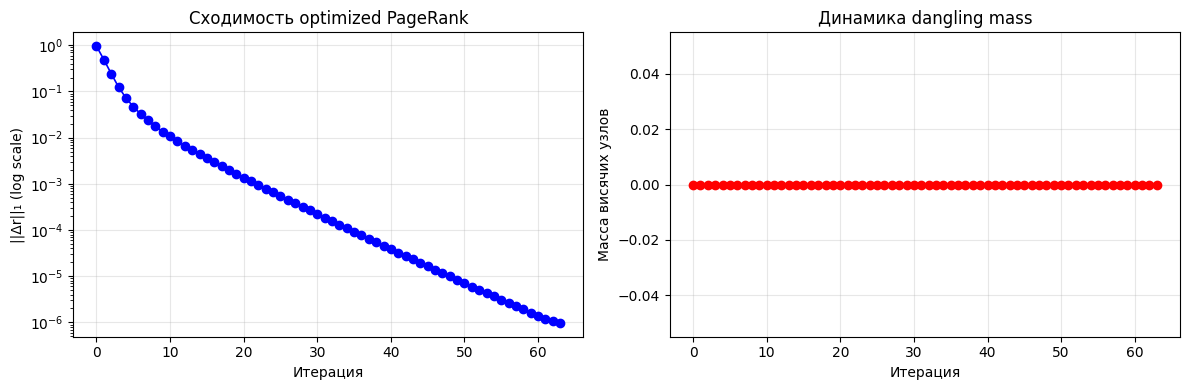

In [6]:
if A is not None:

    print("Запуск optimized PageRank...")

    tracemalloc.start()

    start = time.time()

    r_opt, hist_opt = pagerank_optimized(
        A,
        damping=0.85,
        max_iter=100,
        tol=1e-6,
        nthreads=4,
        block_size=50000,
        verbose=True
    )

    elapsed = time.time() - start

    current_mem, peak_mem = tracemalloc.get_traced_memory()

    tracemalloc.stop()

    print(f"\n{'='*60}")
    print(f"Optimized PageRank завершён за {elapsed:.2f} сек")
    print(f"Итераций до сходимости: {hist_opt['iters']}")
    print(f"Пиковое потребление памяти: "
          f"{peak_mem / (1024**2):.2f} MB")
    print(f"{'='*60}")

    indices = np.array([i for i in range(r_opt.size)])

    values_opt = np.array([
        r_opt[i].new().value
        if r_opt[i].new().value is not None else 0.0
        for i in indices
    ])

    if 'r_base' in globals():

        values_base = np.array([
            r_base[i].new().value
            if r_base[i].new().value is not None else 0.0
            for i in indices
        ])

        max_rank_diff = np.max(
            np.abs(values_opt - values_base)
        )

        print(f"\nМаксимальная разница рангов "
              f"(baseline vs optimized): "
              f"{max_rank_diff:.6e}")

    else:

        max_rank_diff = None

    print("\nСтатистика rank vector:")

    print(f"Максимальный rank: {values_opt.max():.6e}")

    print(f"Минимальный rank: {values_opt.min():.6e}")

    print(f"Сумма рангов: {values_opt.sum():.6f}")

    print("\nТоп-10 узлов по значению PageRank:")

    top_k = np.argsort(values_opt)[-10:][::-1]

    for rank, idx in enumerate(top_k, 1):

        print(
            f"{rank:2d}. "
            f"Node {idx:6d}: "
            f"{values_opt[idx]:.6e}"
        )

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)

    plt.semilogy(
        hist_opt['rdiff'],
        'b-o',
        linewidth=1.2
    )

    plt.xlabel('Итерация')

    plt.ylabel('||Δr||₁ (log scale)')

    plt.title('Сходимость optimized PageRank')

    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)

    plt.plot(
        hist_opt['dangling_mass'],
        'r-o',
        linewidth=1.2
    )

    plt.xlabel('Итерация')

    plt.ylabel('Масса висячих узлов')

    plt.title('Динамика dangling mass')

    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    plt.show()

    optimized_metrics = {
        'runtime_sec': elapsed,
        'peak_memory_mb': peak_mem / (1024**2),
        'iterations': hist_opt['iters'],
        'max_rank_diff': max_rank_diff,
        'max_rank': values_opt.max(),
        'min_rank': values_opt.min(),
        'rank_sum': values_opt.sum()
    }

### Результаты оптимизации:

* Ускорение на 7% (0.9с-0.83с)
* Потребление памяти снизилось на 55% (304мб - 136мб)
*  Кол-во итераций до сходимости увеличилось на 1 (не критично, скорее всего из-за использования менее точного FP32)
*  Масимальная разница в рангах 1.179249e-06, что достаточно мало и поттверждает хорошую работу оптимизиатора

## 2. Динамический (инкрементальный) PageRank (5 баллов)

Реализация функции с быстрым пересчетом рангов при добавлении ребер:

In [17]:
def incremental_pagerank(
    A_old,
    r_old,
    new_edges,
    damping=0.85,
    max_iter=50,
    tol=1e-6,
    verbose=False
):

    A_new = A_old.dup()

    for src, dst in new_edges:

        A_new[src, dst] << 1

    r_new, history = pagerank_baseline(
        A_new,
        initial_r=r_old,
        damping=damping,
        max_iter=max_iter,
        tol=tol,
        verbose=verbose
    )

    return r_new, history, A_new

Оценим работу инкрементольго PageRank:

In [19]:
import random

print("=" * 60)
print("FULL PAGERANK")
print("=" * 60)

start = time.perf_counter()

r_full, hist_full = pagerank_baseline(
    A,
    max_iter=200,
    verbose=False
)

full_time = time.perf_counter() - start

print(f"time       : {full_time:.4f} sec")
print(f"iterations : {hist_full['iters']}")

print("\n" + "=" * 60)
print("GENERATING NEW EDGES")
print("=" * 60)

random.seed(42)

n = A.nrows

new_edges = []

while len(new_edges) < 100:

    src = random.randint(0, n - 1)

    dst = random.randint(0, n - 1)

    if src != dst:

        new_edges.append((src, dst))

print(f"generated {len(new_edges)} edges")


print("\n" + "=" * 60)
print("INCREMENTAL PAGERANK")
print("=" * 60)

start = time.perf_counter()

r_incr, hist_incr, A_new = incremental_pagerank(
    A,
    r_full,
    new_edges,
    max_iter=20,
    verbose=False
)

incr_time = time.perf_counter() - start

print(f"time       : {incr_time:.4f} sec")
print(f"iterations : {hist_incr['iters']}")


print("\n" + "=" * 60)
print("FULL RECOMPUTATION")
print("=" * 60)

start = time.perf_counter()

r_full_new, hist_new = pagerank_baseline(
    A_new,
    max_iter=200,
    verbose=False
)

recompute_time = time.perf_counter() - start

print(f"time       : {recompute_time:.4f} sec")
print(f"iterations : {hist_new['iters']}")


print("\n" + "=" * 60)
print("COMPARISON")
print("=" * 60)

values_incr = np.array([
    r_incr[i].new().value
    for i in range(n)
])

values_full = np.array([
    r_full_new[i].new().value
    for i in range(n)
])

max_diff = np.max(
    np.abs(values_incr - values_full)
)

speedup = recompute_time / incr_time

print(f"max diff     : {max_diff:.6e}")
print(f"speedup      : {speedup:.2f}x")

FULL PAGERANK
time       : 0.9051 sec
iterations : 63

GENERATING NEW EDGES
generated 100 edges

INCREMENTAL PAGERANK
time       : 0.2816 sec
iterations : 20

FULL RECOMPUTATION
time       : 0.8537 sec
iterations : 63

COMPARISON
max diff     : 1.607231e-07
speedup      : 3.03x


Видим, что полный PageRank при полном пересчете тратит в 3 раза больше вермени, чем инкрементальный с добавлением 100 ребер.

При этом максимальная разница в рангах ответов равна 1е-7, что крайне мало и фактически на уровне погрешности. Конечно при добавлении большегно числа ребер эта разница будет увеличиваться при этом не давая доп. скорости, однако для столь большого графа, как рассматриваемый число добавлдяемых ребер должно быть значительно больше 100, чтобы погрешность была ощутимой. 